In [2]:
import pandas as pd

df = pd.read_csv("data/processed/climate_yearly.csv")

df.head()


,station,Stationsname,Bundesland,Höhe [m],Höhenklasse,Jahr,tl_mittel,tlmax_mittel,tlmin_mittel,tage_frost,shneu_manu,tage_schdecke,sh_manu_max,rr
0,1,Aflenz,Steiermark,783.2,500–999 m,1968,6.333333,11.350000,2.116667,145.0,NaN,98.0,60.0,837.0
1,1,Aflenz,Steiermark,783.2,500–999 m,1969,6.166667,11.225000,1.833333,162.0,NaN,112.0,47.0,760.0
2,1,Aflenz,Steiermark,783.2,500–999 m,1970,5.816667,10.758333,1.791667,166.0,NaN,104.0,85.0,1190.0
3,1,Aflenz,Steiermark,783.2,500–999 m,1971,6.033333,11.941667,1.791667,142.0,95.0,70.0,26.0,677.0
4,1,Aflenz,Steiermark,783.2,500–999 m,1972,5.591667,10.916667,1.825000,144.0,85.0,45.0,28.0,1042.0


In [3]:
df.shape

(36098, 14)

In [4]:
temperatur_jahr = (
    df.groupby("Jahr")
    .agg(
        temperatur_mittel=("tl_mittel", "mean"),
        anzahl_stationen=("tl_mittel", "count")
    )
    .reset_index()
)

temperatur_jahr.head()

,Jahr,temperatur_mittel,anzahl_stationen
0,1900,7.057153,43
1,1901,6.110692,53
2,1902,6.093396,53
3,1903,6.544167,50
4,1904,6.932190,53


In [5]:
temperatur_jahr.tail()

,Jahr,temperatur_mittel,anzahl_stationen
121,2021,7.704065,453
122,2022,8.947820,457
123,2023,9.084076,461
124,2024,9.638822,461
125,2025,8.708228,465


In [6]:
temperatur_jahr.sort_values("anzahl_stationen").head(20)

,Jahr,temperatur_mittel,anzahl_stationen
0,1900,7.057153,43
18,1918,6.837065,46
17,1917,6.096099,47
19,1919,6.010090,47
22,1922,6.060322,48
21,1921,7.463370,49
20,1920,7.426824,49
16,1916,7.372016,49
23,1923,7.192007,49
24,1924,6.365646,49


In [7]:
temperatur_jahr.sort_values("anzahl_stationen", ascending=False).head(20)

,Jahr,temperatur_mittel,anzahl_stationen
125,2025,8.708228,465
123,2023,9.084076,461
124,2024,9.638822,461
118,2018,8.985440,458
122,2022,8.947820,457
120,2020,8.570410,456
119,2019,8.889084,455
110,2010,7.035421,455
117,2017,8.252726,454
111,2011,8.245291,453


In [8]:
temp_1960 = df[
    (df["Jahr"] >= 1960) &
    (df["Jahr"] <= 2025)
].copy()

temp_abdeckung = (
    temp_1960.groupby(
        ["station", "Stationsname", "Bundesland", "Höhe [m]", "Höhenklasse"]
    )["tl_mittel"]
    .count()
    .reset_index(name="anzahl_jahre")
)

temp_abdeckung["abdeckung_prozent"] = (
    temp_abdeckung["anzahl_jahre"] / 66 * 100
).round(1)

temp_stationen = temp_abdeckung[
    temp_abdeckung["abdeckung_prozent"] >= 90
]

temp_stationen.shape

(119, 7)

In [9]:
temp_stationen["Höhenklasse"].value_counts().sort_index()

Höhenklasse
1000–1499 m    20
500–999 m      43
ab 1500 m       8
unter 500 m    48
Name: count, dtype: int64

In [10]:
temp_stationen["Bundesland"].value_counts()

Bundesland
Niederösterreich    23
Tirol               23
Steiermark          19
Kärnten             16
Oberösterreich      14
Salzburg            12
Burgenland           5
Vorarlberg           4
Wien                 3
Name: count, dtype: int64

In [11]:
temp_ids = temp_stationen["station"]

temp_final = temp_1960[
    temp_1960["station"].isin(temp_ids)
].copy()

temp_final.shape

(7711, 14)

In [12]:
referenz_temp = (
    temp_final[
        (temp_final["Jahr"] >= 1961) &
        (temp_final["Jahr"] <= 1990)
    ]
    .groupby("station")["tl_mittel"]
    .mean()
)

temp_final["referenz_temp"] = temp_final["station"].map(referenz_temp)

temp_final["temp_anomalie"] = (
    temp_final["tl_mittel"] - temp_final["referenz_temp"]
)

In [13]:
temp_trend = (
    temp_final.groupby("Jahr")
    .agg(
        temp_anomalie=("temp_anomalie", "mean"),
        anzahl_stationen=("temp_anomalie", "count")
    )
    .reset_index()
)

temp_trend.tail(10)

,Jahr,temp_anomalie,anzahl_stationen
56,2016,1.588497,116
57,2017,1.440778,118
58,2018,2.242820,119
59,2019,2.132757,119
60,2020,1.806129,118
61,2021,0.958399,117
62,2022,2.215584,118
63,2023,2.368486,118
64,2024,2.924378,117
65,2025,1.970753,118


In [14]:
temp_hoehenlage = (
    temp_final.groupby(
        ["Jahr", "Höhenklasse"],
        observed=True
    )
    .agg(
        temp_anomalie=("temp_anomalie", "mean"),
        anzahl_stationen=("temp_anomalie", "count")
    )
    .reset_index()
)

temp_hoehenlage.head()

,Jahr,Höhenklasse,temp_anomalie,anzahl_stationen
0,1960,1000–1499 m,0.266225,19
1,1960,500–999 m,0.325270,37
2,1960,ab 1500 m,0.086399,8
3,1960,unter 500 m,0.209839,41
4,1961,1000–1499 m,1.052708,19


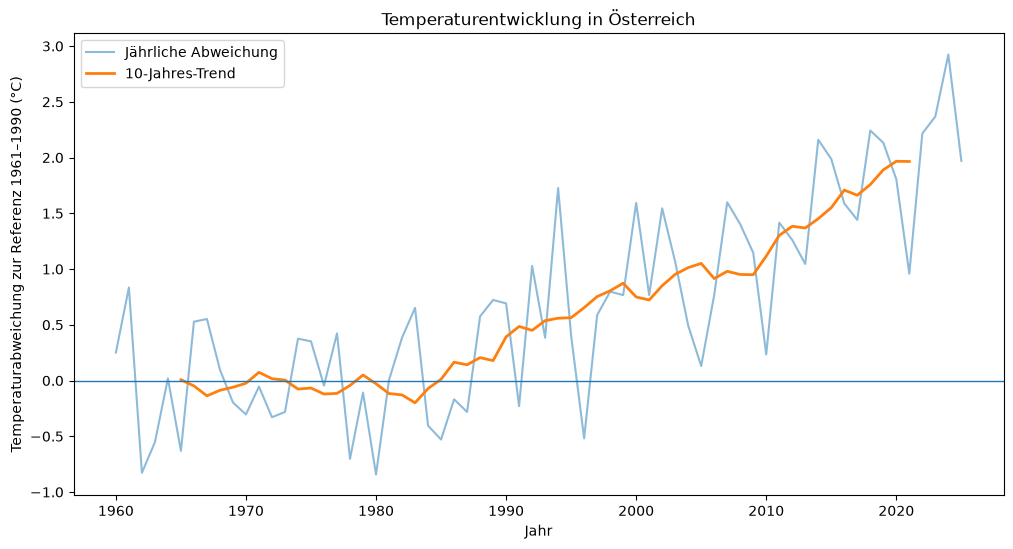

In [15]:
import matplotlib.pyplot as plt

temp_trend["trend_10_jahre"] = (
    temp_trend["temp_anomalie"]
    .rolling(window=10, center=True)
    .mean()
)

plt.figure(figsize=(12, 6))

plt.plot(
    temp_trend["Jahr"],
    temp_trend["temp_anomalie"],
    alpha=0.5,
    label="Jährliche Abweichung"
)

plt.plot(
    temp_trend["Jahr"],
    temp_trend["trend_10_jahre"],
    linewidth=2,
    label="10-Jahres-Trend"
)

plt.axhline(0, linewidth=1)

plt.title("Temperaturentwicklung in Österreich")
plt.xlabel("Jahr")
plt.ylabel("Temperaturabweichung zur Referenz 1961–1990 (°C)")
plt.legend()

plt.show()

In [16]:
temp_hoehen_trend = (
    temp_final.groupby(
        ["Jahr", "Höhenklasse"],
        observed=True
    )["temp_anomalie"]
    .mean()
    .reset_index()
)

temp_hoehen_trend["trend_10_jahre"] = (
    temp_hoehen_trend
    .groupby("Höhenklasse", observed=True)["temp_anomalie"]
    .transform(lambda x: x.rolling(10, center=True).mean())
)

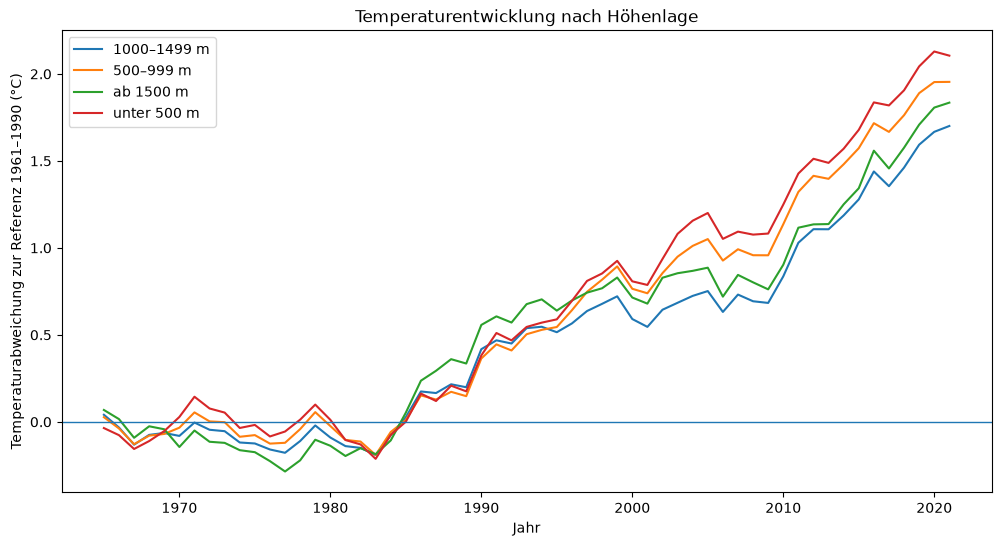

In [17]:
plt.figure(figsize=(12, 6))

for hoehe in temp_hoehen_trend["Höhenklasse"].unique():
    daten = temp_hoehen_trend[
        temp_hoehen_trend["Höhenklasse"] == hoehe
    ]

    plt.plot(
        daten["Jahr"],
        daten["trend_10_jahre"],
        label=hoehe
    )

plt.axhline(0, linewidth=1)

plt.title("Temperaturentwicklung nach Höhenlage")
plt.xlabel("Jahr")
plt.ylabel("Temperaturabweichung zur Referenz 1961–1990 (°C)")
plt.legend()

plt.show()

In [18]:
import numpy as np

trend_hoehe = []

for hoehe in temp_final["Höhenklasse"].dropna().unique():

    daten = temp_final[
        temp_final["Höhenklasse"] == hoehe
    ]

    jahreswerte = (
        daten.groupby("Jahr")["temp_anomalie"]
        .mean()
        .dropna()
    )

    steigung, achsenabschnitt = np.polyfit(
        jahreswerte.index,
        jahreswerte.values,
        1
    )

    trend_hoehe.append({
        "Höhenklasse": hoehe,
        "Trend °C pro Jahrzehnt": round(steigung * 10, 3),
        "Stationen": daten["station"].nunique()
    })

trend_hoehe = pd.DataFrame(trend_hoehe)

trend_hoehe.sort_values(
    "Trend °C pro Jahrzehnt",
    ascending=False
)

,Höhenklasse,Trend °C pro Jahrzehnt,Stationen
1,unter 500 m,0.397,48
0,500–999 m,0.366,43
3,ab 1500 m,0.335,8
2,1000–1499 m,0.308,20


In [19]:
frost_abdeckung = (
    temp_1960.groupby(
        ["station", "Stationsname", "Bundesland", "Höhe [m]", "Höhenklasse"]
    )["tage_frost"]
    .count()
    .reset_index(name="anzahl_jahre")
)

frost_abdeckung["abdeckung_prozent"] = (
    frost_abdeckung["anzahl_jahre"] / 66 * 100
).round(1)

frost_stationen = frost_abdeckung[
    frost_abdeckung["abdeckung_prozent"] >= 90
]

frost_stationen.shape

(118, 7)

In [20]:
frost_stationen["Höhenklasse"].value_counts().sort_index()

Höhenklasse
1000–1499 m    20
500–999 m      42
ab 1500 m       8
unter 500 m    48
Name: count, dtype: int64

In [21]:
schnee_abdeckung = (
    temp_1960.groupby(
        ["station", "Stationsname", "Bundesland", "Höhe [m]", "Höhenklasse"]
    )["tage_schdecke"]
    .count()
    .reset_index(name="anzahl_jahre")
)

schnee_abdeckung["abdeckung_prozent"] = (
    schnee_abdeckung["anzahl_jahre"] / 66 * 100
).round(1)

schnee_stationen = schnee_abdeckung[
    schnee_abdeckung["abdeckung_prozent"] >= 90
]

schnee_stationen.shape

(77, 7)

In [22]:
schnee_stationen["Höhenklasse"].value_counts().sort_index()

Höhenklasse
1000–1499 m    11
500–999 m      28
ab 1500 m       5
unter 500 m    33
Name: count, dtype: int64

In [23]:
frost_ids = frost_stationen["station"]

frost_final = temp_1960[
    temp_1960["station"].isin(frost_ids)
].copy()

frost_trend_hoehe = (
    frost_final.groupby(
        ["Jahr", "Höhenklasse"],
        observed=True
    )["tage_frost"]
    .mean()
    .reset_index()
)

frost_trend_hoehe["trend_10_jahre"] = (
    frost_trend_hoehe
    .groupby("Höhenklasse", observed=True)["tage_frost"]
    .transform(lambda x: x.rolling(10, center=True).mean())
)

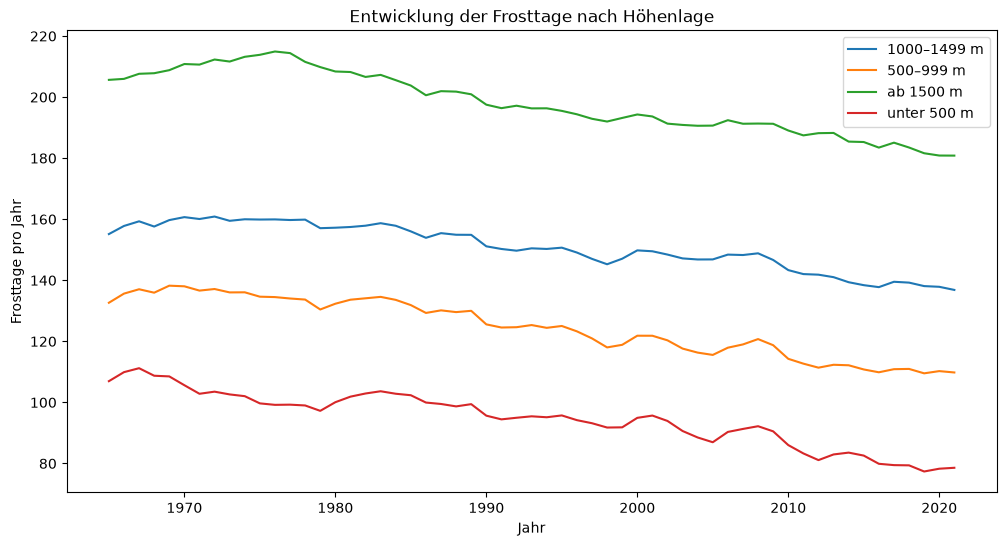

In [24]:
plt.figure(figsize=(12, 6))

for hoehe in frost_trend_hoehe["Höhenklasse"].unique():
    daten = frost_trend_hoehe[
        frost_trend_hoehe["Höhenklasse"] == hoehe
    ]

    plt.plot(
        daten["Jahr"],
        daten["trend_10_jahre"],
        label=hoehe
    )

plt.title("Entwicklung der Frosttage nach Höhenlage")
plt.xlabel("Jahr")
plt.ylabel("Frosttage pro Jahr")
plt.legend()

plt.show()

In [25]:
schnee_ids = schnee_stationen["station"]

schnee_final = temp_1960[
    temp_1960["station"].isin(schnee_ids)
].copy()

schnee_trend_hoehe = (
    schnee_final.groupby(
        ["Jahr", "Höhenklasse"],
        observed=True
    )["tage_schdecke"]
    .mean()
    .reset_index()
)

schnee_trend_hoehe["trend_10_jahre"] = (
    schnee_trend_hoehe
    .groupby("Höhenklasse", observed=True)["tage_schdecke"]
    .transform(lambda x: x.rolling(10, center=True).mean())
)

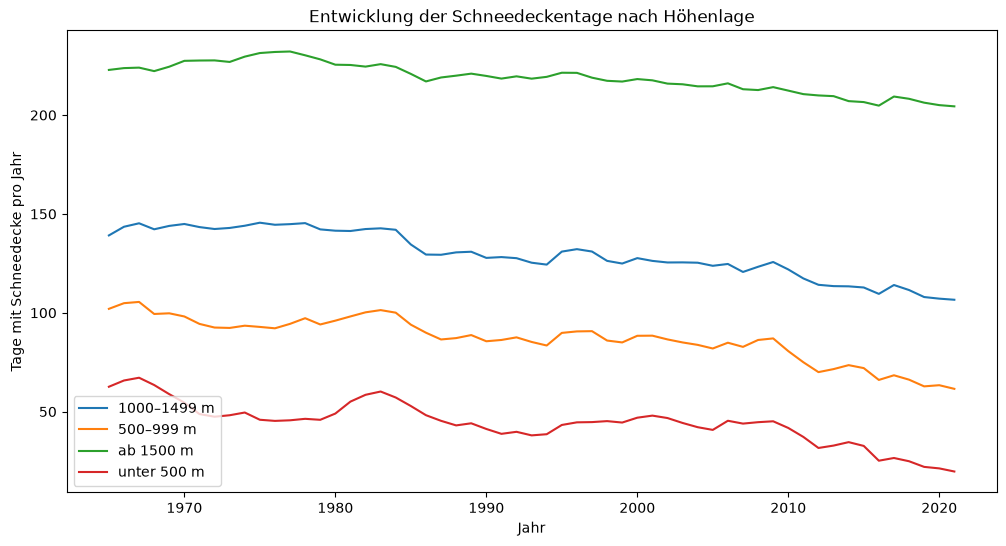

In [26]:
plt.figure(figsize=(12, 6))

for hoehe in schnee_trend_hoehe["Höhenklasse"].unique():
    daten = schnee_trend_hoehe[
        schnee_trend_hoehe["Höhenklasse"] == hoehe
    ]

    plt.plot(
        daten["Jahr"],
        daten["trend_10_jahre"],
        label=hoehe
    )

plt.title("Entwicklung der Schneedeckentage nach Höhenlage")
plt.xlabel("Jahr")
plt.ylabel("Tage mit Schneedecke pro Jahr")
plt.legend()

plt.show()

In [27]:
trend_frost = []

for hoehe in frost_final["Höhenklasse"].dropna().unique():

    daten = frost_final[
        frost_final["Höhenklasse"] == hoehe
    ]

    jahreswerte = (
        daten.groupby("Jahr")["tage_frost"]
        .mean()
        .dropna()
    )

    steigung, achsenabschnitt = np.polyfit(
        jahreswerte.index,
        jahreswerte.values,
        1
    )

    trend_frost.append({
        "Höhenklasse": hoehe,
        "Trend Frosttage pro Jahrzehnt": round(steigung * 10, 1),
        "Stationen": daten["station"].nunique()
    })

trend_frost = pd.DataFrame(trend_frost)

trend_frost.sort_values(
    "Trend Frosttage pro Jahrzehnt"
)

,Höhenklasse,Trend Frosttage pro Jahrzehnt,Stationen
3,ab 1500 m,-5.5,8
1,unter 500 m,-4.9,48
0,500–999 m,-4.8,42
2,1000–1499 m,-3.9,20


In [28]:
trend_schnee = []

for hoehe in schnee_final["Höhenklasse"].dropna().unique():

    daten = schnee_final[
        schnee_final["Höhenklasse"] == hoehe
    ]

    jahreswerte = (
        daten.groupby("Jahr")["tage_schdecke"]
        .mean()
        .dropna()
    )

    steigung, achsenabschnitt = np.polyfit(
        jahreswerte.index,
        jahreswerte.values,
        1
    )

    trend_schnee.append({
        "Höhenklasse": hoehe,
        "Trend Schneedeckentage pro Jahrzehnt": round(steigung * 10, 1),
        "Stationen": daten["station"].nunique()
    })

trend_schnee = pd.DataFrame(trend_schnee)

trend_schnee.sort_values(
    "Trend Schneedeckentage pro Jahrzehnt"
)

,Höhenklasse,Trend Schneedeckentage pro Jahrzehnt,Stationen
0,500–999 m,-6.6,28
2,1000–1499 m,-6.6,11
1,unter 500 m,-6.1,33
3,ab 1500 m,-4.1,5


In [29]:
temp_bundesland = (
    temp_final.groupby(
        ["Jahr", "Bundesland"]
    )["temp_anomalie"]
    .mean()
    .reset_index()
)

temp_bundesland["trend_10_jahre"] = (
    temp_bundesland
    .groupby("Bundesland")["temp_anomalie"]
    .transform(lambda x: x.rolling(10, center=True).mean())
)

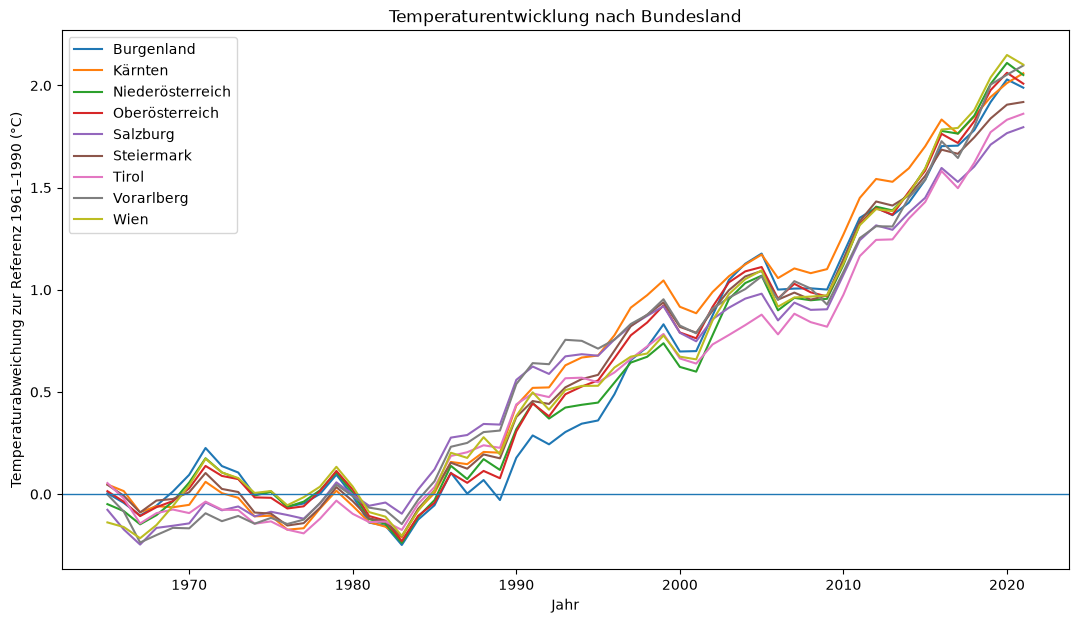

In [30]:
plt.figure(figsize=(13, 7))

for bundesland in temp_bundesland["Bundesland"].unique():

    daten = temp_bundesland[
        temp_bundesland["Bundesland"] == bundesland
    ]

    plt.plot(
        daten["Jahr"],
        daten["trend_10_jahre"],
        label=bundesland
    )

plt.axhline(0, linewidth=1)

plt.title("Temperaturentwicklung nach Bundesland")
plt.xlabel("Jahr")
plt.ylabel("Temperaturabweichung zur Referenz 1961–1990 (°C)")
plt.legend()

plt.show()

In [31]:
trend_bundesland = []

for bundesland in temp_final["Bundesland"].dropna().unique():

    daten = temp_final[
        temp_final["Bundesland"] == bundesland
    ]

    jahreswerte = (
        daten.groupby("Jahr")["temp_anomalie"]
        .mean()
        .dropna()
    )

    steigung, _ = np.polyfit(
        jahreswerte.index,
        jahreswerte.values,
        1
    )

    trend_bundesland.append({
        "Bundesland": bundesland,
        "Trend °C pro Jahrzehnt": round(steigung * 10, 3),
        "Stationen": daten["station"].nunique()
    })

trend_bundesland = pd.DataFrame(trend_bundesland)

trend_bundesland.sort_values(
    "Trend °C pro Jahrzehnt",
    ascending=False
)

,Bundesland,Trend °C pro Jahrzehnt,Stationen
2,Kärnten,0.393,16
8,Wien,0.393,3
5,Vorarlberg,0.383,4
1,Niederösterreich,0.377,23
7,Oberösterreich,0.374,14
4,Burgenland,0.368,5
0,Steiermark,0.364,19
3,Salzburg,0.351,12
6,Tirol,0.339,23
